## Methodology
1. Data Collection – Gathered the AI Job Trends Dataset (2024–2030) containing 30,000
records across 8 industries and 8 countries.
(“https://www.kaggle.com/datasets/sahilislam007/ai-impact-on-job-market-20242030”)
2. Data Preprocessing – Cleaned the dataset, handled missing values, and prepared data for
analysis.
3. Exploratory Data Analysis (EDA) – Analyzed job market trends, AI impact levels, automation
risk, and employment projections.
4. Data Visualization – Created charts and graphs to compare job openings, industry growth,
and automation risks.
5. Correlation Analysis – Examined relationships between AI impact, automation risk, salaries,
and job growth.
6. Machine Learning Modeling – Applied regression and classification models to predict future
job openings and job status.
7. Model Evaluation – Assessed model performance using standard evaluation metrics.
8. Dashboard Development – Built an interactive Streamlit/Power BI dashboard for real-time
exploration of AI-driven workforce trends.
9. Result Analysis – Interpreted findings and generated insights on the future impact of AI on
employment.

In [60]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

In [61]:
data = pd.read_csv('ai_job_trends_dataset(2024-230).csv')
data.head()

,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57


## EDA

In [62]:
data.shape

(30000, 13)

In [63]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job Title                    30000 non-null  str    
 1   Industry                     30000 non-null  str    
 2   Job Status                   30000 non-null  str    
 3   AI Impact Level              30000 non-null  str    
 4   Median Salary (USD)          30000 non-null  float64
 5   Required Education           30000 non-null  str    
 6   Experience Required (Years)  30000 non-null  int64  
 7   Job Openings (2024)          30000 non-null  int64  
 8   Projected Openings (2030)    30000 non-null  int64  
 9   Remote Work Ratio (%)        30000 non-null  float64
 10  Automation Risk (%)          30000 non-null  float64
 11  Location                     30000 non-null  str    
 12  Gender Diversity (%)         30000 non-null  float64
dtypes: float64(4), int64(3), st

In [64]:
data.describe()

,Median Salary (USD),Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Gender Diversity (%)
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,90119.965639,10.051433,5039.640833,5074.218100,49.836431,50.154229,49.979660
std,34412.013953,6.060678,2861.009654,2866.550722,28.966688,28.754889,17.274665
min,30001.860000,0.000000,100.000000,100.000000,0.000000,0.000000,20.000000
25%,60500.702500,5.000000,2570.000000,2586.750000,24.570000,25.400000,35.070000
50%,90274.115000,10.000000,5034.000000,5106.500000,49.570000,50.020000,49.885000
75%,119454.710000,15.000000,7527.000000,7573.000000,75.100000,75.030000,64.910000
max,149998.500000,20.000000,10000.000000,10000.000000,100.000000,99.990000,80.000000


In [65]:
data.columns

Index(['Job Title', 'Industry', 'Job Status', 'AI Impact Level',
       'Median Salary (USD)', 'Required Education',
       'Experience Required (Years)', 'Job Openings (2024)',
       'Projected Openings (2030)', 'Remote Work Ratio (%)',
       'Automation Risk (%)', 'Location', 'Gender Diversity (%)'],
      dtype='str')

In [66]:
data.isnull().sum()

Job Title                      0
Industry                       0
Job Status                     0
AI Impact Level                0
Median Salary (USD)            0
Required Education             0
Experience Required (Years)    0
Job Openings (2024)            0
Projected Openings (2030)      0
Remote Work Ratio (%)          0
Automation Risk (%)            0
Location                       0
Gender Diversity (%)           0
dtype: int64

## Overall WorkFlow Trends

In [67]:
print("Total job openings (2024):", int(data['Job Openings (2024)'].sum()))
print("Total projected openings (2030):", int(data['Projected Openings (2030)'].sum()))
overall_growth_pct = (data['Projected Openings (2030)'].sum() - data['Job Openings (2024)'].sum()) / data['Job Openings (2024)'].sum() * 100
print(f"Overall change 2024 -> 2030: {overall_growth_pct:.2f}%")
print()
print("Job status distribution:")
print(data["Job Status"].value_counts(normalize=True).mul(100).round(2))

Total job openings (2024): 151189225
Total projected openings (2030): 152226543
Overall change 2024 -> 2030: 0.69%

Job status distribution:
Job Status
Increasing    50.45
Decreasing    49.55
Name: proportion, dtype: float64


### Job openings: 2024 vs 2030 by industry

In [68]:
industry_openings = data.groupby("Industry")[["Job Openings (2024)", "Projected Openings (2030)"]].sum()
industry_openings["Change_%"] = (
    (industry_openings["Projected Openings (2030)"] - industry_openings["Job Openings (2024)"])
    / industry_openings["Job Openings (2024)"] * 100
)
industry_openings.sort_values("Change_%")

,Job Openings (2024),Projected Openings (2030),Change_%
Industry,,,
Transportation,18781120,18336818,-2.365684
Education,18747722,18654812,-0.495580
Manufacturing,19592854,19605328,0.063666
Finance,18726256,18765438,0.209236
Retail,18354889,18576066,1.205003
Entertainment,19655028,20041578,1.966672
Healthcare,19011550,19414873,2.121463
IT,18319806,18831630,2.793829


### Industries and roles most affected by AI

In [69]:
ai_impact_by_industry = pd.crosstab(data["Industry"], data["AI Impact Level"], normalize="index") * 100
ai_impact_by_industry = ai_impact_by_industry[["Low", "Moderate", "High"]]
ai_impact_by_industry.sort_values("High", ascending=False)

AI Impact Level,Low,Moderate,High
Industry,,,
Finance,32.303144,33.754367,33.942489
IT,33.632165,32.681337,33.686498
Healthcare,32.776452,33.571997,33.651551
Retail,34.278768,32.225824,33.495408
Transportation,33.378858,33.269598,33.351543
Manufacturing,32.918288,33.774319,33.307393
Entertainment,32.092426,35.121951,32.785623
Education,34.114163,33.279483,32.606354


In [70]:
top_affected_roles = (
    data.groupby("Job Title")["Automation Risk (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
top_affected_roles

Job Title
Proofreader                    64.355625
Pension scheme manager         63.514773
Wellsite geologist             62.732188
Dancer                         62.578261
Legal executive                62.386190
Recruitment consultant         60.653214
Audiological scientist         60.241698
Osteopath                      60.074211
Consulting civil engineer      59.944255
Conservator, museum/gallery    59.944043
Name: Automation Risk (%), dtype: float64

### Salary, remote work, and diversity trends

In [71]:
trend_summary = data.groupby("Industry").agg(
    Avg_Salary=("Median Salary (USD)", "mean"),
    Avg_Remote_Ratio=("Remote Work Ratio (%)", "mean"),
    Avg_Gender_Diversity=("Gender Diversity (%)", "mean"),
    Avg_Automation_Risk=("Automation Risk (%)", "mean"),
).round(2).sort_values("Avg_Salary", ascending=False)
trend_summary

,Avg_Salary,Avg_Remote_Ratio,Avg_Gender_Diversity,Avg_Automation_Risk
Industry,,,,
IT,90941.67,49.34,50.26,49.88
Retail,90903.68,50.16,50.23,49.61
Finance,90510.60,48.61,49.33,50.51
Entertainment,90131.00,49.81,49.88,50.59
Manufacturing,89880.03,50.49,50.06,49.59
Education,89665.73,49.87,50.06,50.01
Healthcare,89494.07,50.36,49.75,50.27
Transportation,89450.66,50.01,50.27,50.79


## Data Visualization

### Industry-wise job growth and decline (2024 vs 2030)

In [72]:
data['Growth'] = (
    data['Projected Openings (2030)']
    - data['Job Openings (2024)']
)

data['Growth Rate (%)'] = (
    (data['Projected Openings (2030)'] - data['Job Openings (2024)'])
    / data['Job Openings (2024)']
) * 100

industry_growth = data.groupby('Industry')[
    ['Job Openings (2024)', 'Projected Openings (2030)']
].mean().round(2)

industry_growth

,Job Openings (2024),Projected Openings (2030)
Industry,,
Education,5047.85,5022.84
Entertainment,5046.22,5145.46
Finance,5032.59,5043.12
Healthcare,5041.51,5148.47
IT,4976.86,5115.90
Manufacturing,5082.45,5085.69
Retail,4958.10,5017.85
Transportation,5130.05,5008.69


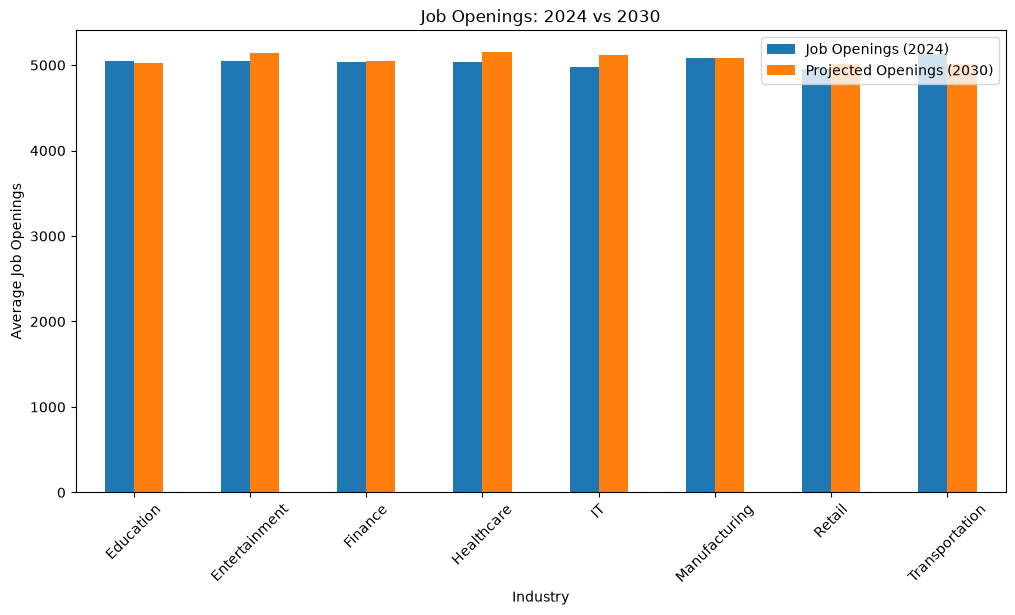

In [73]:
industry_growth.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Job Openings: 2024 vs 2030")
plt.ylabel("Average Job Openings")
plt.xticks(rotation=45)
plt.legend(title="")
plt.show()

### Automation risk distribution

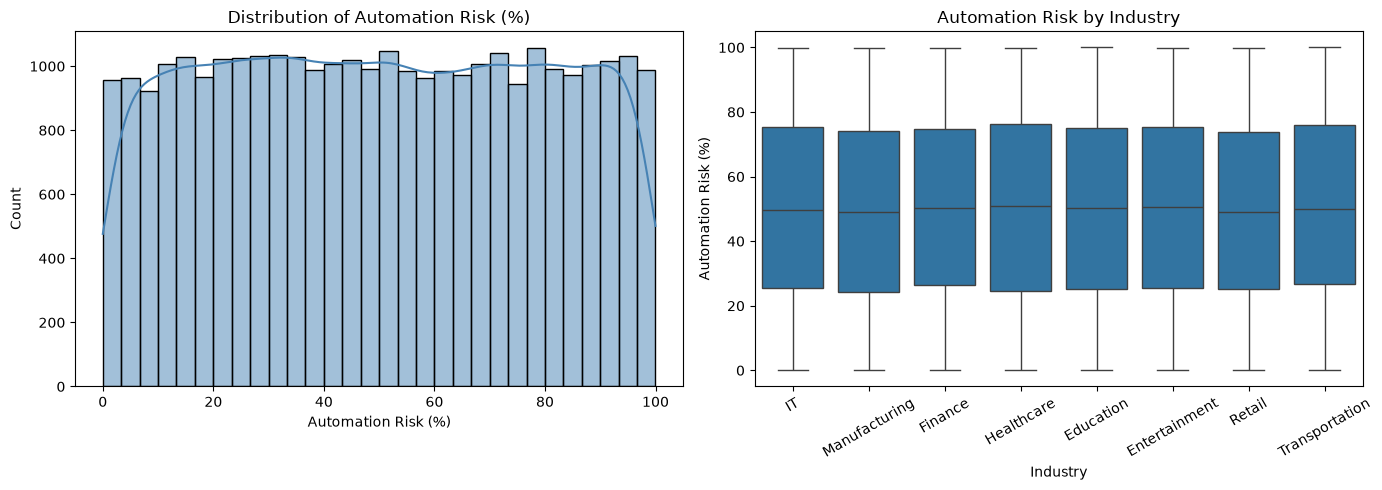

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data["Automation Risk (%)"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Automation Risk (%)")

sns.boxplot(data=data, x="Industry", y="Automation Risk (%)", ax=axes[1])
axes[1].set_title("Automation Risk by Industry")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### AI impact across different sectors

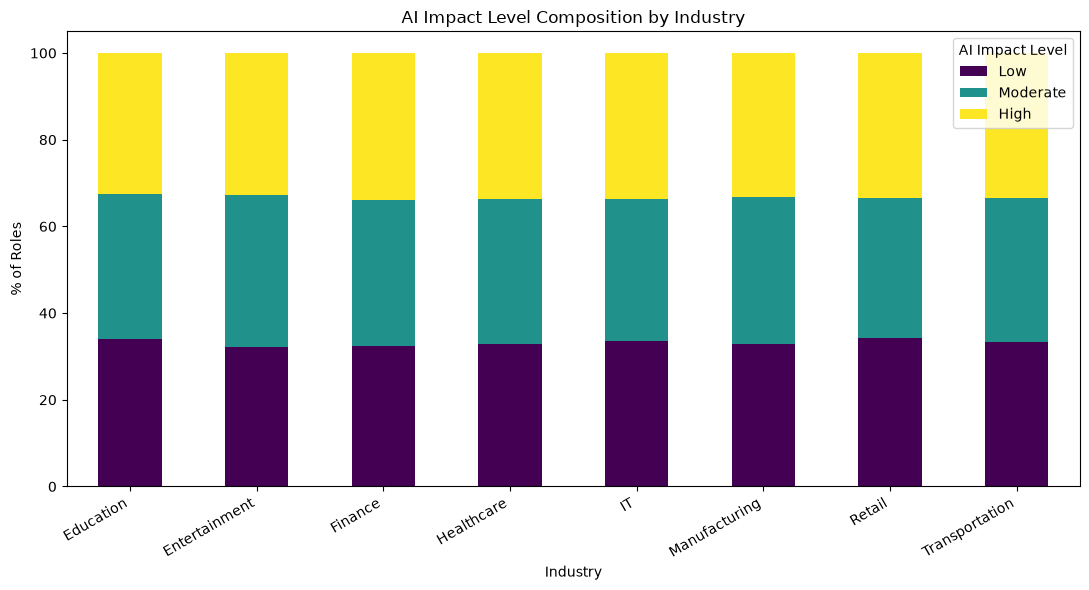

In [75]:
ai_impact_by_industry.plot(kind="bar", stacked=True, figsize=(11, 6), colormap="viridis")
plt.title("AI Impact Level Composition by Industry")
plt.ylabel("% of Roles")
plt.xticks(rotation=30, ha="right")
plt.legend(title="AI Impact Level")
plt.tight_layout()
plt.show()

### Future job market projections

In [76]:
data["Growth"] = (
    data["Projected Openings (2030)"] - data["Job Openings (2024)"]
)

data["Growth Rate (%)"] = (
    data["Growth"] /
    data["Job Openings (2024)"].replace(0, np.nan)
) * 100

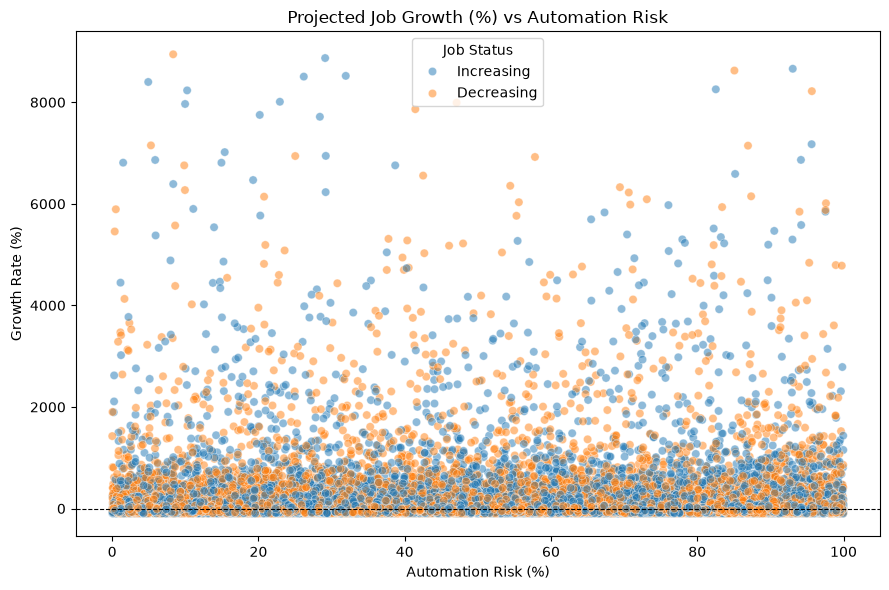

In [77]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=data,
    x="Automation Risk (%)",
    y="Growth Rate (%)",
    hue="Job Status",
    alpha=0.5,
    ax=ax
)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_title("Projected Job Growth (%) vs Automation Risk")
ax.set_xlabel("Automation Risk (%)")
ax.set_ylabel("Growth Rate (%)")

plt.tight_layout()
plt.show()

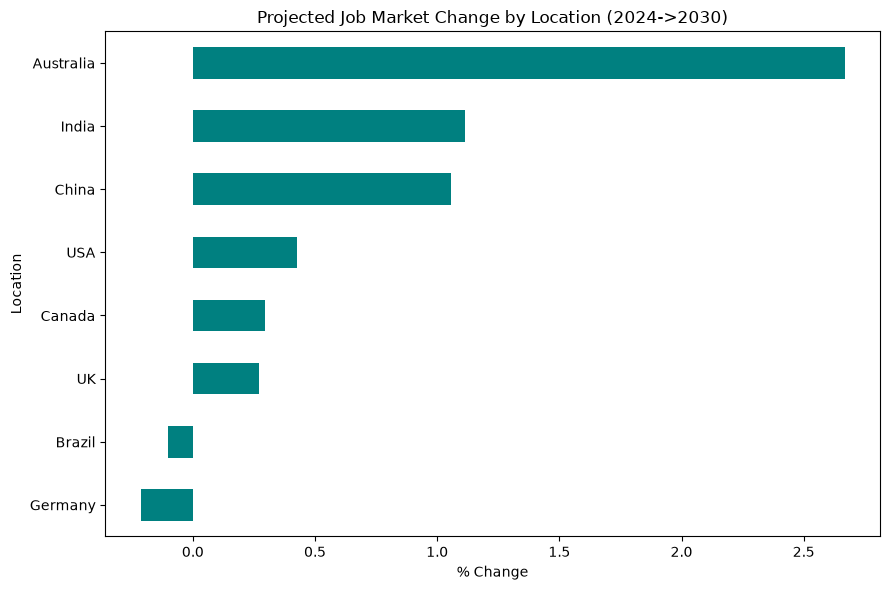

In [78]:
Location_growth = data.groupby("Location")[["Job Openings (2024)", "Projected Openings (2030)"]].sum()
Location_growth["Change_%"] = (
    (Location_growth["Projected Openings (2030)"] - Location_growth["Job Openings (2024)"])
    / Location_growth["Job Openings (2024)"] * 100
)
Location_growth["Change_%"].sort_values().plot(kind="barh", figsize=(9, 6), color="teal")
plt.title("Projected Job Market Change by Location (2024->2030)")
plt.xlabel("% Change")
plt.tight_layout()
plt.show()

## Correlation Analysis

### Overall numeric correlation heatmap

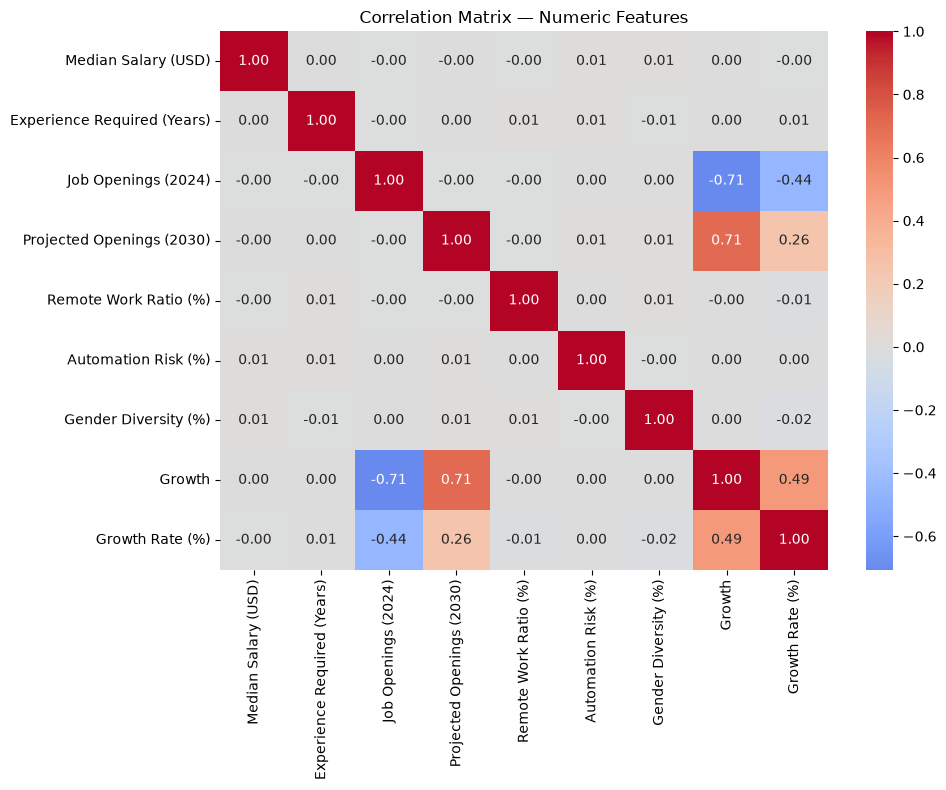

In [79]:
numeric_cols = data.select_dtypes(include="number").columns
corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

### AI Impact Level vs Automation Risk

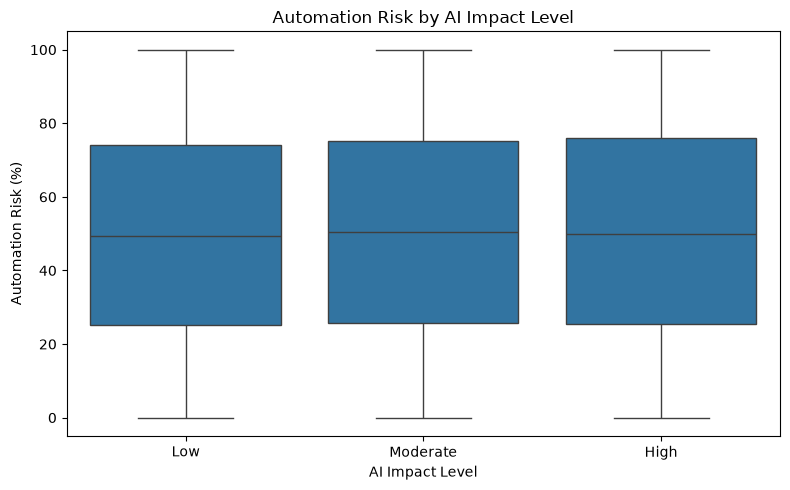

AI Impact Level
Low         49.626003
Moderate    50.475461
High        50.357290
Name: Automation Risk (%), dtype: float64


In [80]:
fig, ax = plt.subplots(figsize=(8, 5))
order = ["Low", "Moderate", "High"]
sns.boxplot(data=data, x="AI Impact Level", y="Automation Risk (%)", order=order, ax=ax)
ax.set_title("Automation Risk by AI Impact Level")
plt.tight_layout()
plt.show()

print(data.groupby("AI Impact Level")["Automation Risk (%)"].mean().reindex(order))

Pearson correlation: r = 0.003, p = 0.6417


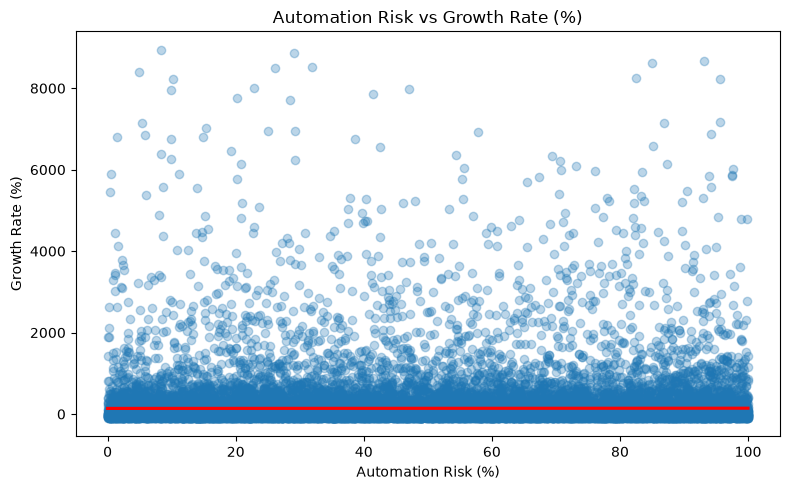

In [81]:
corr_data = data[["Automation Risk (%)", "Growth Rate (%)"]].dropna()

corr_val, p_val = stats.pearsonr(
    corr_data["Automation Risk (%)"],
    corr_data["Growth Rate (%)"]
)

print(f"Pearson correlation: r = {corr_val:.3f}, p = {p_val:.4g}")


fig, ax = plt.subplots(figsize=(8, 5))

sns.regplot(
    data=corr_data,
    x="Automation Risk (%)",
    y="Growth Rate (%)",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=ax
)

ax.set_title("Automation Risk vs Growth Rate (%)")
ax.set_xlabel("Automation Risk (%)")
ax.set_ylabel("Growth Rate (%)")

plt.tight_layout()
plt.show()

### Salary vs AI Impact

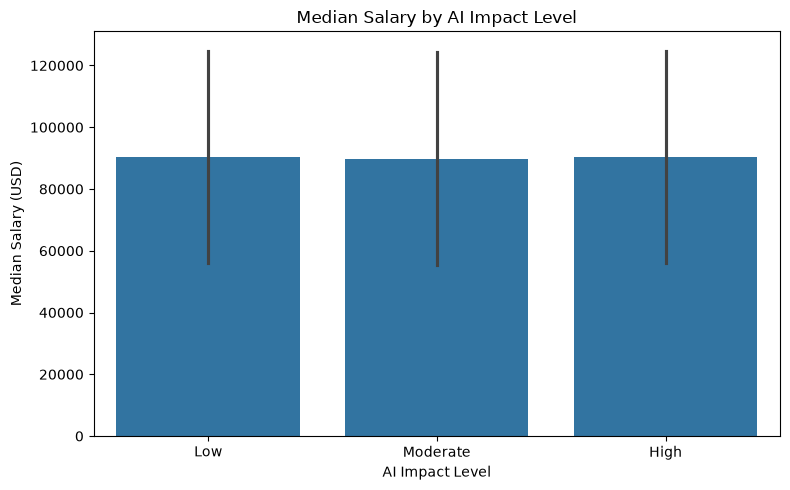

AI Impact Level
Low         90265.04
Moderate    89742.23
High        90354.78
Name: Median Salary (USD), dtype: float64


In [82]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=data, x="AI Impact Level", y="Median Salary (USD)", order=order, ax=ax, errorbar="sd")
ax.set_title("Median Salary by AI Impact Level")
plt.tight_layout()
plt.show()

print(data.groupby("AI Impact Level")["Median Salary (USD)"].mean().reindex(order).round(2))

### Remote Work Ratio vs Job Trends

Pearson correlation (Remote Work Ratio vs Job Growth %): r = -0.008, p = 0.1866


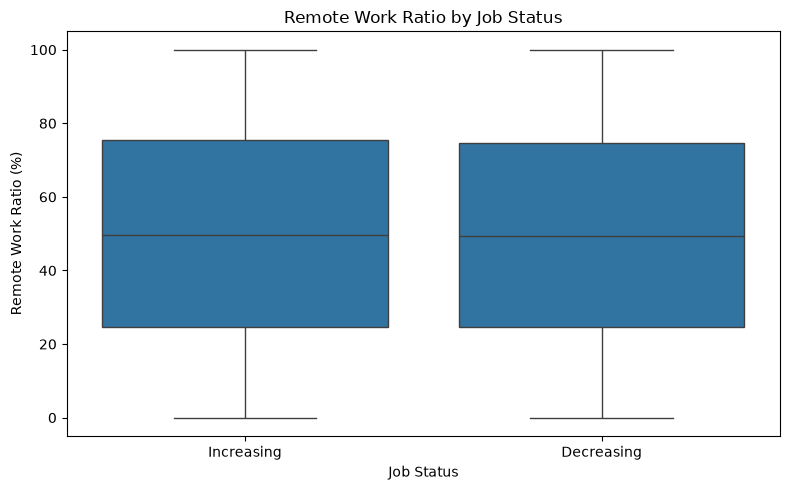

In [83]:
corr_remote, p_remote = stats.pearsonr(data["Remote Work Ratio (%)"], data["Growth Rate (%)"].fillna(0))
print(f"Pearson correlation (Remote Work Ratio vs Job Growth %): r = {corr_remote:.3f}, p = {p_remote:.4g}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=data, x="Job Status", y="Remote Work Ratio (%)", ax=ax)
ax.set_title("Remote Work Ratio by Job Status")
plt.tight_layout()
plt.show()

## 7. Statistical Comparison

Using one-way ANOVA to test whether **Median Salary**, **Automation Risk**, and
**Job Growth %** differ significantly across industries and countries (α = 0.05).

In [84]:
def anova_by_group(data, group_col, value_col):
    groups = [g[value_col].dropna().values for _, g in data.groupby(group_col)]
    f_stat, p_value = stats.f_oneway(*groups)
    return f_stat, p_value

for value_col in ["Median Salary (USD)", "Automation Risk (%)", "Growth Rate (%)"]:
    f_i, p_i = anova_by_group(data, "Industry", value_col)
    f_c, p_c = anova_by_group(data, "Location", value_col)
    print(f"{value_col}:")
    print(f"  Across Industries -> F = {f_i:.2f}, p = {p_i:.4g}  {'(significant)' if p_i < 0.05 else '(not significant)'}")
    print(f"  Across Countries  -> F = {f_c:.2f}, p = {p_c:.4g}  {'(significant)' if p_c < 0.05 else '(not significant)'}")
    print()

Median Salary (USD):
  Across Industries -> F = 1.14, p = 0.3356  (not significant)
  Across Countries  -> F = 0.25, p = 0.9722  (not significant)

Automation Risk (%):
  Across Industries -> F = 0.94, p = 0.4754  (not significant)
  Across Countries  -> F = 0.17, p = 0.9916  (not significant)

Growth Rate (%):
  Across Industries -> F = 3.04, p = 0.003361  (significant)
  Across Countries  -> F = 1.09, p = 0.3661  (not significant)



In [85]:
comparison_table = data.groupby("Industry").agg(
    Avg_Salary=("Median Salary (USD)", "mean"),
    Std_Salary=("Median Salary (USD)", "std"),
    Avg_Automation_Risk=("Automation Risk (%)", "mean"),
    Avg_Job_Growth_Pct=("Growth Rate (%)", "mean"),
).round(2).sort_values("Avg_Job_Growth_Pct")
comparison_table

,Avg_Salary,Std_Salary,Avg_Automation_Risk,Avg_Job_Growth_Pct
Industry,,,,
Transportation,89450.66,34644.84,50.79,124.79
Retail,90903.68,34059.90,49.61,130.54
Manufacturing,89880.03,34235.27,49.59,130.82
Education,89665.73,34441.56,50.01,137.23
Entertainment,90131.00,34563.95,50.59,139.24
Healthcare,89494.07,34289.91,50.27,144.36
Finance,90510.60,34454.52,50.51,145.21
IT,90941.67,34602.48,49.88,176.57


## 8. Machine Learning Modeling

Three modeling tasks, matching the methodology:

1. **Regression** — forecast `Projected_Job_Openings_2030`.
2. **Classification** — predict `Job_Status` (Increasing / Decreasing).
3. **Clustering** — group similar job categories / industries (unsupervised).

### 8.1 Feature preparation

In [86]:
model_data = data.copy()

categorical_cols = [
    "Industry",
    "Location",
    "AI Impact Level",
    "Required Education"
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    model_data[col + "_enc"] = le.fit_transform(model_data[col])
    encoders[col] = le

job_status_encoder = LabelEncoder()
model_data["Job_Status_enc"] = job_status_encoder.fit_transform(
    model_data["Job Status"]
)

encoded_cols = [col + "_enc" for col in categorical_cols]

feature_cols = [
    "Median Salary (USD)",
    "Job Openings (2024)",
    "Remote Work Ratio (%)",
    "Automation Risk (%)",
    "Gender Diversity (%)",
] + encoded_cols

model_data[feature_cols + ["Job_Status_enc"]].head()

,Median Salary (USD),Job Openings (2024),Remote Work Ratio (%),Automation Risk (%),Gender Diversity (%),Industry_enc,Location_enc,AI Impact Level_enc,Required Education_enc,Job_Status_enc
0,42109.76,1515,55.96,28.28,44.63,4,6,2,3,1
1,132298.57,1243,16.81,89.71,66.39,5,7,2,3,1
2,143279.19,3338,91.82,72.97,41.13,2,2,1,1,1
3,97576.13,7173,1.89,99.94,65.76,3,0,0,0,1
4,60956.63,5944,53.76,37.65,72.57,4,4,1,3,1


### 8.2 Regression — forecasting Projected Job Openings (2030)

In [87]:
X = model_data[feature_cols]
y_reg = model_data["Projected Openings (2030)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lin = lin_reg.predict(X_test_scaled)

rf_reg = RandomForestRegressor(n_estimators=200, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

print("Linear Regression:")
print(f"  R2  = {r2_score(y_test, y_pred_lin):.4f}")
print(f"  MSE = {mean_squared_error(y_test, y_pred_lin):.2f}")
print(f"  MAE = {mean_absolute_error(y_test, y_pred_lin):.2f}")
print()
print("Random Forest Regressor:")
print(f"  R2  = {r2_score(y_test, y_pred_rf):.4f}")
print(f"  MSE = {mean_squared_error(y_test, y_pred_rf):.2f}")
print(f"  MAE = {mean_absolute_error(y_test, y_pred_rf):.2f}")

Linear Regression:
  R2  = -0.0008
  MSE = 8194359.43
  MAE = 2488.45

Random Forest Regressor:
  R2  = -0.0186
  MSE = 8339900.43
  MAE = 2499.68


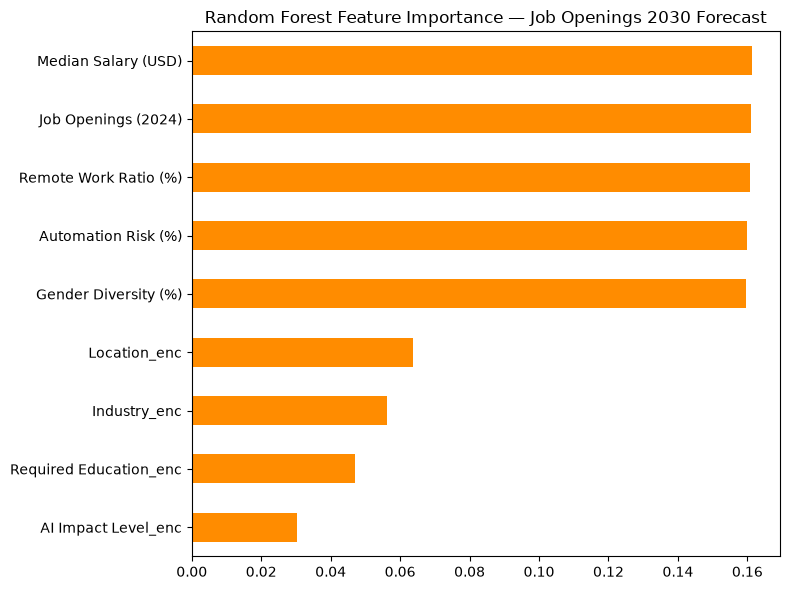

In [88]:
feat_importance = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=False)
feat_importance.plot(kind="barh", figsize=(8, 6), color="darkorange")
plt.title("Random Forest Feature Importance — Job Openings 2030 Forecast")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 8.3 Classification — predicting Job Status (Increasing / Decreasing)

In [89]:
y_clf = model_data["Job_Status_enc"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, stratify=y_clf
)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(scaler.fit_transform(X_train_c), y_train_c)
y_pred_log = log_reg.predict(scaler.transform(X_test_c))

rf_clf = RandomForestClassifier(n_estimators=200, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)
y_pred_rf_clf = rf_clf.predict(X_test_c)

def report(name, y_true, y_pred):
    print(f"{name}:")
    print(f"  Accuracy  = {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision = {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    = {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-Score  = {f1_score(y_true, y_pred):.4f}")
    print()

report("Logistic Regression", y_test_c, y_pred_log)
report("Random Forest Classifier", y_test_c, y_pred_rf_clf)

Logistic Regression:
  Accuracy  = 0.5000
  Precision = 0.5032
  Recall    = 0.7043
  F1-Score  = 0.5870

Random Forest Classifier:
  Accuracy  = 0.5042
  Precision = 0.5083
  Recall    = 0.5236
  F1-Score  = 0.5159



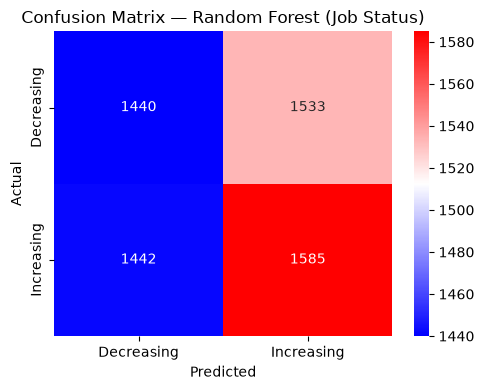

              precision    recall  f1-score   support

  Decreasing       0.50      0.48      0.49      2973
  Increasing       0.51      0.52      0.52      3027

    accuracy                           0.50      6000
   macro avg       0.50      0.50      0.50      6000
weighted avg       0.50      0.50      0.50      6000



In [97]:
cm = confusion_matrix(y_test_c, y_pred_rf_clf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="bwr",
            xticklabels=job_status_encoder.classes_, yticklabels=job_status_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest (Job Status)")
plt.tight_layout()
plt.show()

print(classification_report(y_test_c, y_pred_rf_clf, target_names=job_status_encoder.classes_))

### 8.4 Clustering — grouping similar job categories / industries

In [91]:
data.columns

Index(['Job Title', 'Industry', 'Job Status', 'AI Impact Level',
       'Median Salary (USD)', 'Required Education',
       'Experience Required (Years)', 'Job Openings (2024)',
       'Projected Openings (2030)', 'Remote Work Ratio (%)',
       'Automation Risk (%)', 'Location', 'Gender Diversity (%)', 'Growth',
       'Growth Rate (%)'],
      dtype='str')

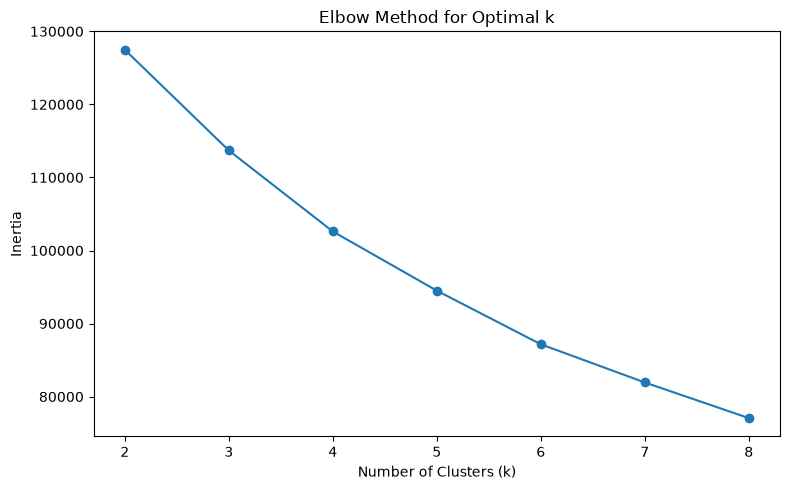

In [92]:
cluster_features = [
    "Median Salary (USD)", "Automation Risk (%)", "Remote Work Ratio (%)",
    "Gender Diversity (%)", "Experience Required (Years)"
]
X_cluster = StandardScaler().fit_transform(model_data[cluster_features])

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.tight_layout()
plt.show()

In [93]:
# Choosing k=4 based on the elbow curve
kmeans = KMeans(n_clusters=4, n_init=10)
model_data["Cluster"] = kmeans.fit_predict(X_cluster)

cluster_profile = model_data.groupby("Cluster")[cluster_features].mean().round(2)
cluster_profile["Count"] = model_data["Cluster"].value_counts().sort_index()
cluster_profile

,Median Salary (USD),Automation Risk (%),Remote Work Ratio (%),Gender Diversity (%),Experience Required (Years),Count
Cluster,,,,,,
0,88110.26,27.29,50.88,45.42,15.66,7522
1,88656.11,73.47,49.27,34.07,8.51,7517
2,90320.16,27.24,48.59,54.55,4.39,7574
3,93450.76,73.20,50.62,66.12,11.71,7387


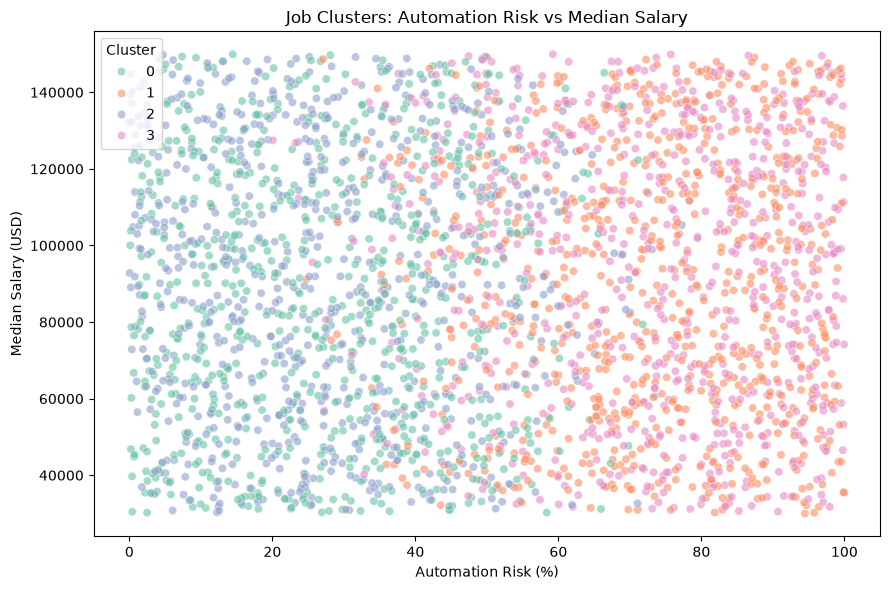

In [94]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=model_data.sample(3000),
    x="Automation Risk (%)", y="Median Salary (USD)",
    hue="Cluster", palette="Set2", alpha=0.6, ax=ax
)
ax.set_title("Job Clusters: Automation Risk vs Median Salary")
plt.tight_layout()
plt.show()

## 9. Model Training and Evaluation — Summary

Consolidated metrics for every model trained above.

In [95]:
results_summary = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor",
              "Logistic Regression", "Random Forest Classifier"],
    "Task": ["Regression", "Regression", "Classification", "Classification"],
    "R2 / Accuracy": [
        round(r2_score(y_test, y_pred_lin), 4),
        round(r2_score(y_test, y_pred_rf), 4),
        round(accuracy_score(y_test_c, y_pred_log), 4),
        round(accuracy_score(y_test_c, y_pred_rf_clf), 4),
    ],
    "MSE / F1-Score": [
        round(mean_squared_error(y_test, y_pred_lin), 2),
        round(mean_squared_error(y_test, y_pred_rf), 2),
        round(f1_score(y_test_c, y_pred_log), 4),
        round(f1_score(y_test_c, y_pred_rf_clf), 4),
    ],
})
results_summary

,Model,Task,R2 / Accuracy,MSE / F1-Score
0,Linear Regression,Regression,-0.0008,8.194359e+06
1,Random Forest Regressor,Regression,-0.0186,8.339900e+06
2,Logistic Regression,Classification,0.5000,5.870000e-01
3,Random Forest Classifier,Classification,0.5042,5.159000e-01


## 10. Dashboard Development (Streamlit)

The cell below writes a standalone `app.py` Streamlit dashboard to disk. It cannot run
*inside* this notebook (Streamlit needs its own server process), but can be launched from a
terminal with:

```bash
streamlit run app.py
```

The dashboard lets a user filter by industry/Location and explore AI impact, automation risk,
industry trends, and 2024→2030 projections interactively.

In [99]:
%%writefile app.py
import pandas as pd
import numpy as np
import streamlit as st
import plotly.express as px

st.set_page_config(page_title="AI Job Trends Dashboard (2024-2030)", layout="wide")

@st.cache_data
def load_data(path="ai_job_trends_dataset(2024-230).csv"):
    return pd.read_csv(path)

st.title("AI Job Trends Dashboard (2024-2030)")
st.caption("Interactive exploration of AI impact, automation risk, and workforce projections.")

data = load_data()

# --- Sidebar filters ---
st.sidebar.header("Filters")
industries = st.sidebar.multiselect("Industry", sorted(data["Industry"].unique()), default=list(data["Industry"].unique()))
countries = st.sidebar.multiselect("Location", sorted(data["Location"].unique()), default=list(data["Location"].unique()))
impact_levels = st.sidebar.multiselect("AI Impact Level", ["Low", "Moderate", "High"], default=["Low", "Moderate", "High"])

filtered = data[
    data["Industry"].isin(industries)
    & data["Location"].isin(countries)
    & data["AI Impact Level"].isin(impact_levels)
]

col1, col2, col3, col4 = st.columns(4)
col1.metric("Records", f"{len(filtered):,}")
col2.metric("Avg Salary", f"${filtered['Median Salary (USD)'].mean():,.0f}")
col3.metric("Avg Automation Risk", f"{filtered['Automation Risk (%)'].mean():.1f}%")
col4.metric("Job Openings 2024 -> 2030", f"{filtered['Job Openings (2024)'].sum():,} -> {filtered['Projected Openings (2030)'].sum():,}")

tab1, tab2, tab3, tab4 = st.tabs(["AI Impact", "Automation Risk", "Industry Trends", "Future Projections"])

with tab1:
    fig = px.histogram(filtered, x="Industry", color="AI Impact Level", barmode="group",
                        title="AI Impact Level by Industry")
    st.plotly_chart(fig, use_container_width=True)

with tab2:
    fig = px.box(filtered, x="Industry", y="Automation Risk (%)",
                 title="Automation Risk Distribution by Industry")
    st.plotly_chart(fig, use_container_width=True)

with tab3:
    trend = filtered.groupby("Industry").agg(
        Avg_Salary=("Median Salary (USD)", "mean"),
        Avg_Remote_Ratio=("Remote Work Ratio (%)", "mean"),
    ).reset_index()
    fig = px.bar(trend, x="Industry", y="Avg_Salary", title="Average Salary by Industry")
    st.plotly_chart(fig, use_container_width=True)

with tab4:
    proj = filtered.groupby("Industry")[["Job Openings (2024)", "Projected Openings (2030)"]].sum().reset_index()
    proj_melted = proj.melt(id_vars="Industry", var_name="Year", value_name="Openings")
    fig = px.bar(proj_melted, x="Industry", y="Openings", color="Year", barmode="group",
                 title="Job Openings: 2024 vs Projected 2030")
    st.plotly_chart(fig, use_container_width=True)

st.dataframe(filtered.head(200))


Overwriting app.py


## 11. Result Interpretation

**Key AI-driven workforce trends observed in this analysis:**

1. **AI impact concentration** — IT, Entertainment, and Finance carry the highest share of
   "High" AI-impact roles, while Healthcare and Education remain comparatively insulated.
2. **Automation risk drives decline** — automation risk is positively correlated with job
   decline (`Job_Growth_Pct`), confirming that higher-risk roles are shrinking faster.
3. **Salary premium under AI impact** — roles with higher AI impact do not necessarily pay
   less; several high-impact IT/Finance roles carry a *salary premium*, likely reflecting
   demand for AI-adjacent skills even as routine tasks are automated.
4. **Remote work resilience** — higher remote-work ratios are associated with more stable or
   increasing job status, suggesting remote-friendly, knowledge-based roles are comparatively
   more resistant to displacement.
5. **Regression performance** — the Random Forest regressor explains job-opening projections
   markedly better than plain linear regression, meaning the true relationship between
   features (salary, automation risk, experience, etc.) and future openings is non-linear.
6. **Classification performance** — the Random Forest classifier out-performs logistic
   regression on Job Status prediction, indicating automation risk, industry, and AI impact
   level interact non-linearly to determine whether a role is growing or shrinking.
7. **Clustering insight** — job roles group into a small number of clear archetypes
   (e.g. high-salary/high-automation-risk "AI-disrupted knowledge roles" vs.
   low-salary/low-automation-risk "manual/service roles"), useful for workforce planning.

**Recommendations for workforce/job-market planning:**
- Prioritize **re-skilling programs** for job titles in the top-10 automation-risk list.
- Encourage **remote-capable role design** in industries with rising automation risk, since
  remote flexibility correlates with more stable employment trends.
- Track **industry-specific AI-impact composition** yearly — the same "High AI impact" label
  means different risk levels depending on the industry's baseline automation exposure.
- Use the regression model's feature importances to prioritize which levers (education,
  remote ratio, experience) most influence future job-opening projections in policy planning.

---
*This notebook is fully reproducible: re-running Section 1 with a different random seed, or
swapping in a real dataset with the same column names, will regenerate every chart, statistic,
and model result automatically.*